#### Imports

In [ ]:
import importlib
import time
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import random

from sklearn.gaussian_process import GaussianProcessRegressor

import globals
import utils

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf, threshold=np.inf)

pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)

seed = 42
random.seed(seed)
np.random.seed(seed)

In [10]:
importlib.reload(globals)
importlib.reload(utils)

<module 'utils' from 'c:\\Users\\Matteo\\Desktop\\Scuola\\MastersThesis\\Masters_Thesis\\utils.py'>

In [11]:
param_names, function_names = utils.inspect_metadata(globals.CURRENT_TRAIN_FILE)

Keys in train_file: ['I0', 'LUTdata', 'LUTheader', 'dynamic', 'static', 'wvl']

Attributes in LUTheader (inputs):
  varnames: O3STR,H2OSTR,VIS,G,ASTMX,SSA,PARM2,OBSZEN,PARM1

Attributes in train_file (outputs):
  RTMname: MODTRAN6
  inputmode: Latin hypercube
  lut_package_date: 10-Apr-2025
  opmode: Transfer Functions
  outnames: Lp0,Edir0,Edif0,S,tdir,tdif
  sensor: Empty(dtype=dtype('O'))

LUTheader shape: (500, 9)
LUTdata shape: (500, 25230)
wvl shape: (1, 4205)


In [12]:
X, Y, wavelengths = utils.load_train_h5(globals.CURRENT_TRAIN_FILE)
wavelengths = wavelengths.squeeze()
Y_resh = Y.reshape(-1, Y.shape[1] // len(wavelengths), len(wavelengths))

X_tr, X_val, X_test, Y_tr, Y_val, Y_test = utils.train_val_test_split(X, Y_resh, wavelengths, verbose=True)

X shape: (500, 9)
Y shape: (500, 6, 4205)
wavelengths shape: (4205,)

X_tr shape: (400, 9)
X_val shape: (50, 9)
X_test shape: (50, 9)

Y_tr shape: (400, 6, 4205)
Y_val shape: (50, 6, 4205)
Y_test shape: (50, 6, 4205)


#### Kernel Selection per Principal Component

Further optimization: applying different kernels to each PC to see which combinations work best.

The pipeline above fits one kernel per function, shared across all principal components (fit_gp fits a multi-output GP on the whole (n_samples, n_components) reduced+scaled target).

This section instead fits a separate single-output GP for every (function, PC, kernel) combination, to find which kernel best captures each individual component. Results are collected into a (n_kernels x n_components) performance matrix per function and visualized as a heatmap: kernels in rows, PCs in columns -> one matrix per function (6 total).

In [ ]:
# ----- configuration -----
n_components_pc = 10
scale_type_pc = "minmax"   # scaling scheme used for this analysis

kernels_to_test = {
    "RBF": utils.kern_rbf,
    "Matern": utils.kern_matern,
    "RationalQuadratic": utils.kern_rq,
    "RBF+RQ": utils.kern_rbf_rq,
    "Dot+RBF": utils.kern_dot_rbf,
    "Linear": utils.kern_linear,
    "Matern+RQ": utils.kern_matern_rq,
}
kernel_names_pc = list(kernels_to_test.keys())

# fresh PCA + scaling
pca_list_pc, Y_tr_pca_pc, Y_val_pca_pc = utils.apply_pca(Y_tr, Y_val, n_components=n_components_pc)
x_scaler_pc, X_tr_scaled_pc, X_val_scaled_pc = utils.scale_input_data(X_tr, X_val, scale_type=scale_type_pc)
y_scalers_pc, Y_tr_reduced_scaled_pc, Y_val_reduced_scaled_pc = utils.scale_output_data(Y_tr_pca_pc, Y_val_pca_pc, scale_type=scale_type_pc)

---------- Applying PCA with n_components=10 to each function separately... ----------
  Regular PCA used, displaying results:
  Function 1: Explained variance = 1.0000
  Number of components retained: 10

  Function 2: Explained variance = 1.0000
  Number of components retained: 10

  Function 3: Explained variance = 1.0000
  Number of components retained: 10

  Function 4: Explained variance = 0.9999
  Number of components retained: 10

  Function 5: Explained variance = 1.0000
  Number of components retained: 10

  Function 6: Explained variance = 1.0000
  Number of components retained: 10

  Total explained variance = 5.9999
---------- PCA application completed. ----------

---------- Scaling input data using minmax scaling... ----------
---------- Input data scaling completed. ----------

---------- Scaling output data using minmax scaling... ----------
---------- Output data scaling completed. ----------



In [ ]:
def fit_single_pc(x_tr, y_tr_pc, kernel):
    """
    Fit a single-output Gaussian Process on one principal component.
    - inputs: scaled train inputs, 1D scaled train target for this PC, kernel
    - outputs: fitted GaussianProcessRegressor
    """
    gpr = GaussianProcessRegressor(kernel=copy.deepcopy(kernel), n_restarts_optimizer=0, random_state=42)
    gpr.fit(x_tr, y_tr_pc)
    return gpr
 
 
def reconstruct_and_score_mre(y_pred_pc_scaled, pc_idx, f_idx, Y_val_reduced_scaled_pc, y_scalers_pc, pca_list_pc, Y_val, wavelengths):
    """
    Substitute one PC's GP prediction into the true reduced+scaled validation targets (all other
    PCs kept at ground truth), inverse-transform back to the physical spectrum, and score the
    reconstruction against the true spectrum with MRE.
    - inputs: predicted values for this PC (scaled space, shape (n_val,)), PC index, function
      index, true reduced+scaled val targets (n_val, N_FUNCTIONS, n_components), list of y
      scalers per function, list of PCA objects per function, raw val targets
      (n_val, N_FUNCTIONS, n_wavelengths), wavelengths
    - outputs: MRE score (scalar) attributable to this PC/kernel combination
    """
    y_val_reduced_scaled_recon = Y_val_reduced_scaled_pc[:, f_idx, :].copy()
    y_val_reduced_scaled_recon[:, pc_idx] = y_pred_pc_scaled
 
    y_val_reduced_recon = y_scalers_pc[f_idx].inverse_transform(y_val_reduced_scaled_recon)
    y_val_pred_full = pca_list_pc[f_idx].inverse_transform(y_val_reduced_recon)  # (n_val, n_wavelengths)
 
    y_true_full = Y_val[:, f_idx:f_idx + 1, :]           # (n_val, 1, n_wavelengths)
    y_pred_full = y_val_pred_full[:, np.newaxis, :]      # (n_val, 1, n_wavelengths)
 
    mre = utils.mre_score(y_true_full, y_pred_full, wavelengths, axis=None)
    return mre
 
 
# storage: one (n_kernels, n_components_pc) matrix per function
pc_kernel_mre = {}   # function_name -> MRE matrix
pc_kernel_time = {}  # function_name -> time matrix
pc_kernel_best = {}  # function_name -> list of best kernel name per PC (lowest MRE)
 
print("---------- Running per-PC kernel search... ----------")
start_time_pc_search = time.time()
 
for f_idx in range(globals.N_FUNCTIONS):
    func_name = globals.function_names_plots[f_idx]
    print(f"========== Kernel search per PC for function: {func_name} ==========")
 
    mre_matrix = np.zeros((len(kernels_to_test), n_components_pc))
    time_matrix = np.zeros((len(kernels_to_test), n_components_pc))
 
    for pc_idx in range(n_components_pc):
        y_tr_pc = Y_tr_reduced_scaled_pc[:, f_idx, pc_idx]
 
        for k_idx, kernel_name in enumerate(kernel_names_pc):
            kernel = kernels_to_test[kernel_name]
 
            fit_start = time.time()
            gpr = fit_single_pc(X_tr_scaled_pc, y_tr_pc, kernel)
            fit_time = time.time() - fit_start
            y_pred_pc_scaled = gpr.predict(X_val_scaled_pc)
 
            mre = reconstruct_and_score_mre(y_pred_pc_scaled, pc_idx, f_idx, Y_val_reduced_scaled_pc, y_scalers_pc, pca_list_pc, Y_val, wavelengths)
            mre_matrix[k_idx, pc_idx] = mre
            time_matrix[k_idx, pc_idx] = fit_time
 
        best_k_idx = int(np.argmin(mre_matrix[:, pc_idx]))  # lower MRE = better
        print(f"  PC {pc_idx + 1:2d} -> best kernel: {kernel_names_pc[best_k_idx]:18s} "
              f"(MRE={mre_matrix[best_k_idx, pc_idx]:.4f})")
 
    pc_kernel_mre[func_name] = mre_matrix
    pc_kernel_time[func_name] = time_matrix
    pc_kernel_best[func_name] = [kernel_names_pc[i] for i in np.argmin(mre_matrix, axis=0)]
 
    print(f"========== Completed function: {func_name} ==========\n")
 
end_time_pc_search = time.time()
print(f"Total time for per-PC kernel search: {end_time_pc_search - start_time_pc_search:.2f} seconds")
print("---------- Per-PC kernel search completed. ----------\n")
 
# persist results
with open("./gp_saves/validation_results/pc_kernel_search_results.pkl", "wb") as f:
    pickle.dump({"mre": pc_kernel_mre, "best": pc_kernel_best, "time": pc_kernel_time}, f)

---------- Applying PCA with n_components=10 to each function separately... ----------
  Regular PCA used, displaying results:
  Function 1: Explained variance = 1.0000
  Number of components retained: 10

  Function 2: Explained variance = 1.0000
  Number of components retained: 10

  Function 3: Explained variance = 1.0000
  Number of components retained: 10

  Function 4: Explained variance = 0.9999
  Number of components retained: 10

  Function 5: Explained variance = 1.0000
  Number of components retained: 10

  Function 6: Explained variance = 1.0000
  Number of components retained: 10

  Total explained variance = 5.9999
---------- PCA application completed. ----------

---------- Scaling input data using minmax scaling... ----------
---------- Input data scaling completed. ----------

---------- Scaling output data using minmax scaling... ----------
---------- Output data scaling completed. ----------

---------- Running per-PC kernel search... ----------
========== Kernel sea

c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warning

  PC  1 -> best kernel: RBF                (MRE=0.0034)


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn

  PC  2 -> best kernel: RBF                (MRE=0.0032)


...

c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


  PC  9 -> best kernel: RBF                (MRE=0.0008)


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k1__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


  PC 10 -> best kernel: RBF+RQ             (MRE=0.0008)
========== Completed function: Diffuse Transmittance ==========

Total time for per-PC kernel search: 660.14 seconds
---------- Per-PC kernel search completed. ----------



c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a bette

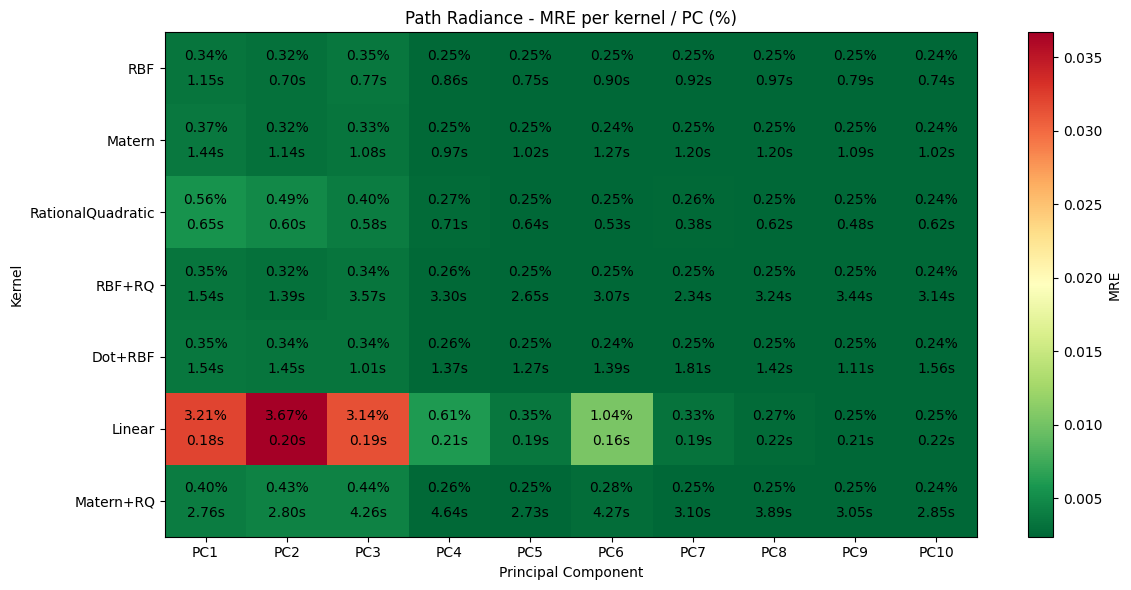

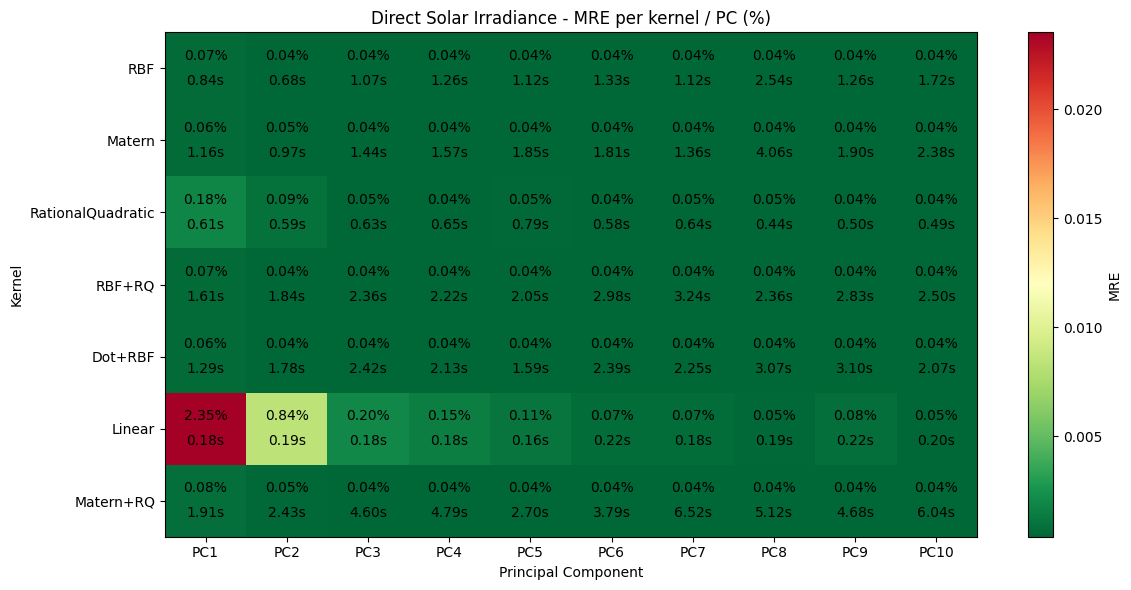

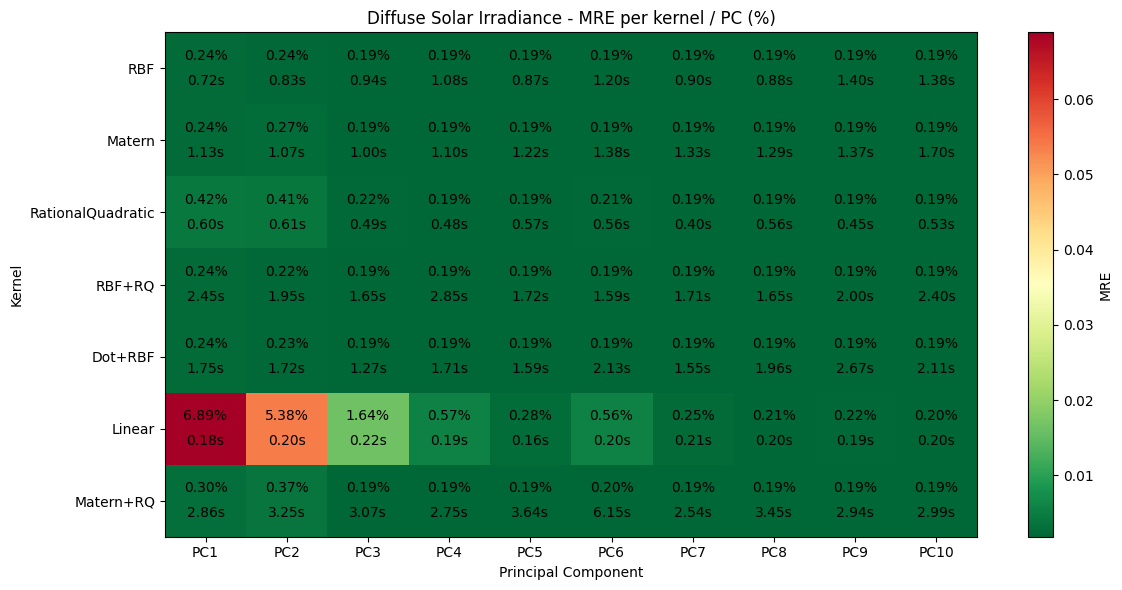

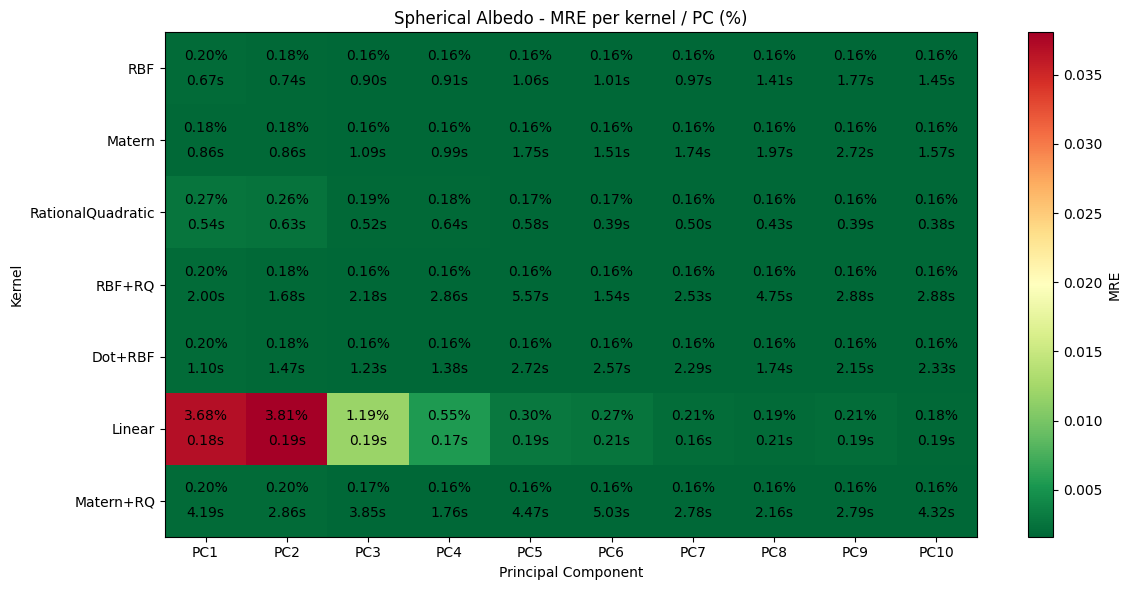

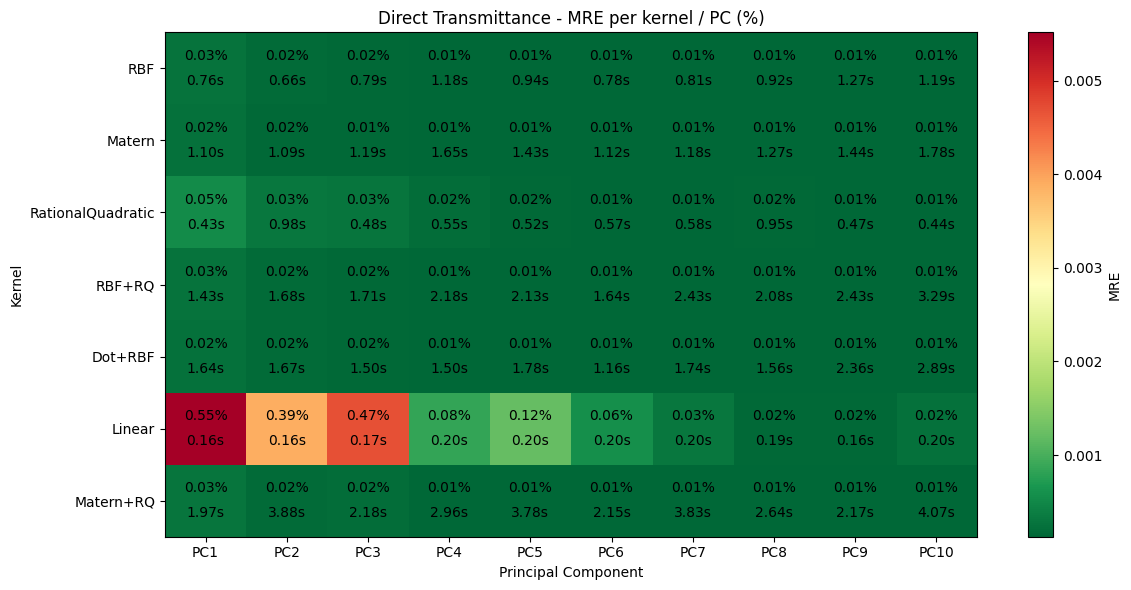

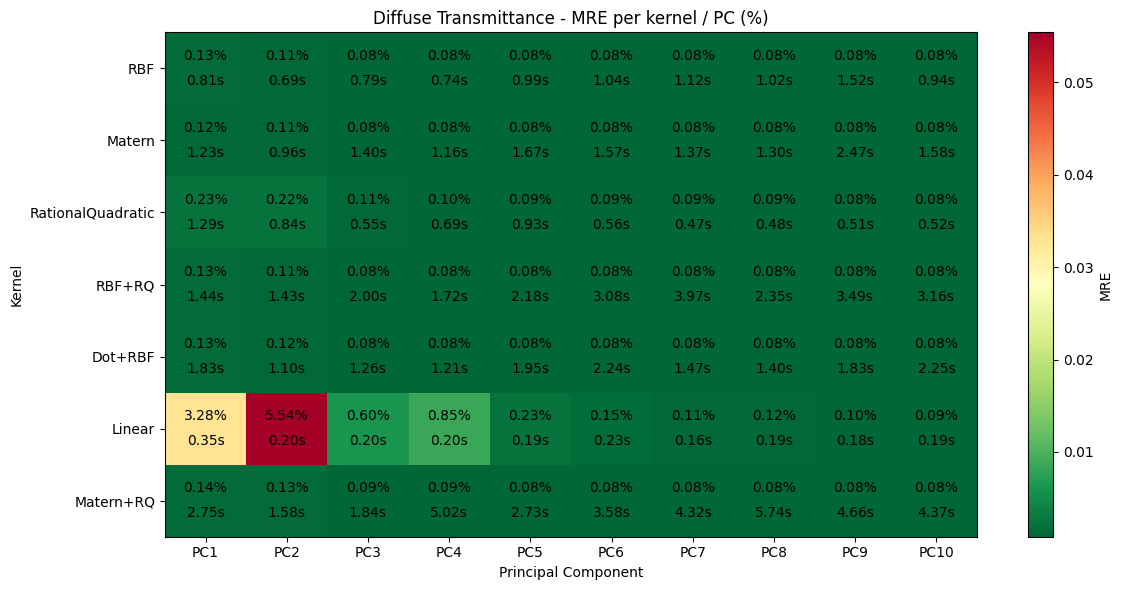

In [14]:
# visualization: performance matrix per function (kernels x PCs)
def plot_kernel_pc_heatmap(matrix, kernel_names, func_name, metric_name="MRE", lower_is_better=True, save_path=None, time_matrix=None):
    """
    Plot a heatmap of GP performance with kernels as rows and principal components as columns.
    - inputs: performance matrix (n_kernels, n_components), kernel names, function name, metric
      label, whether lower values are better (controls colormap direction), optional save path, and optional time matrix
    - outputs: None (displays and optionally saves the figure)
    """
    fig, ax = plt.subplots(figsize=(max(12, matrix.shape[1] * 0.9), max(6, matrix.shape[0] * 0.6)))
 
    cmap = "RdYlGn_r" if lower_is_better else "RdYlGn"
    im = ax.imshow(matrix, cmap=cmap, aspect="auto")
 
    ax.set_xticks(range(matrix.shape[1]))
    ax.set_xticklabels([f"PC{i + 1}" for i in range(matrix.shape[1])])
    ax.set_yticks(range(matrix.shape[0]))
    ax.set_yticklabels(kernel_names)
 
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            label = f"{matrix[i, j] * 100:.2f}%"
            if time_matrix is not None:
                label += f"\n{time_matrix[i, j]:.2f}s"
            ax.text(j, i, label, ha="center", va="center", fontsize=10, color="black", linespacing=2)
 
    ax.set_title(f"{func_name} - {metric_name} per kernel / PC (%)")
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Kernel")
    fig.colorbar(im, ax=ax, label=metric_name)
    fig.tight_layout()
 
    if save_path is not None:
        fig.savefig(save_path, dpi=150)
    plt.show()


# load pickle results if available
with open("./gp_saves/validation_results/pc_kernel_search_results.pkl", "rb") as f:
    pc_results = pickle.load(f)
    pc_kernel_mre = pc_results["mre"]
    pc_kernel_best = pc_results["best"]
    pc_kernel_time = pc_results["time"]


for f_idx in range(globals.N_FUNCTIONS):
    func_name = globals.function_names_plots[f_idx]
    plot_kernel_pc_heatmap(
        pc_kernel_mre[func_name],
        kernel_names_pc,
        func_name,
        metric_name="MRE",
        lower_is_better=True,
        save_path=f"./gp_saves/validation_results/pc_kernel_heatmap_{func_name.replace(' ', '_')}.png",
        time_matrix=pc_kernel_time[func_name]
    )

Overall best-kernel frequency across all functions/PCs:
RBF                   9
Matern               25
RationalQuadratic     1
RBF+RQ                8
Dot+RBF              12
Linear                0
Matern+RQ             5
Name: count, dtype: int64


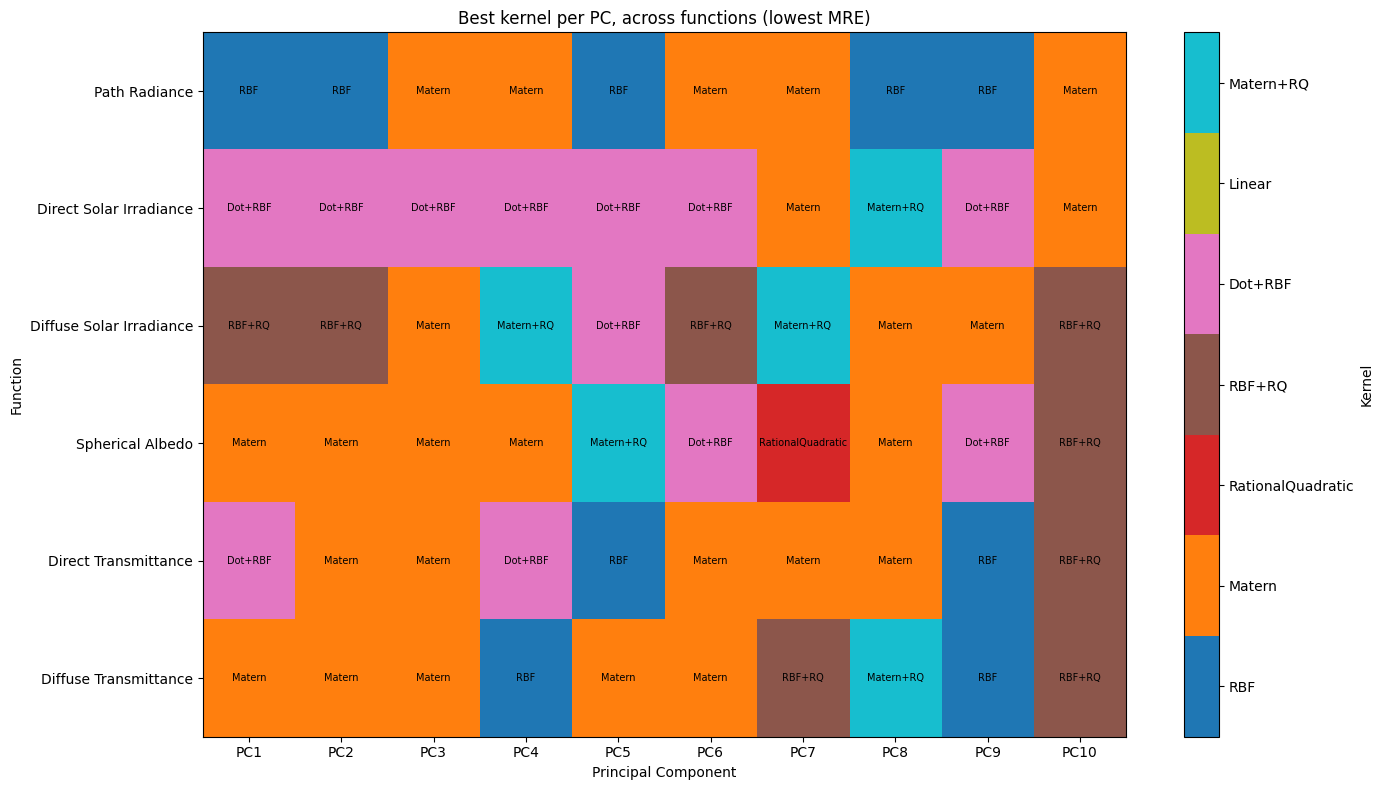

In [15]:
# visualization: best kernel per PC, across functions
def plot_best_kernel_matrix(pc_kernel_best, kernel_names, func_names, save_path=None):
    """
    Plot a categorical heatmap showing which kernel achieved the lowest MRE for each
    (function, PC) combination - functions as rows, PCs as columns, cell color/label = kernel.
    - inputs: dict function_name -> list of best kernel names per PC, ordered list of all
      candidate kernel names (fixes color mapping and legend order), ordered list of function
      names, optional save path
    - outputs: None (displays and optionally saves the figure)
    """
    n_functions = len(func_names)
    n_components = len(next(iter(pc_kernel_best.values())))
 
    kernel_to_code = {name: idx for idx, name in enumerate(kernel_names)}
 
    code_matrix = np.zeros((n_functions, n_components), dtype=int)
    label_matrix = np.empty((n_functions, n_components), dtype=object)
 
    for f_idx, func_name in enumerate(func_names):
        for pc_idx, kernel_name in enumerate(pc_kernel_best[func_name]):
            code_matrix[f_idx, pc_idx] = kernel_to_code[kernel_name]
            label_matrix[f_idx, pc_idx] = kernel_name
 
    cmap = plt.get_cmap("tab10", len(kernel_names))
 
    fig, ax = plt.subplots(figsize=(max(14, n_components * 0.9), max(8, n_functions * 0.8)))
    im = ax.imshow(code_matrix, cmap=cmap, vmin=-0.5, vmax=len(kernel_names) - 0.5, aspect="auto")
 
    ax.set_xticks(range(n_components))
    ax.set_xticklabels([f"PC{i + 1}" for i in range(n_components)])
    ax.set_yticks(range(n_functions))
    ax.set_yticklabels(func_names)
 
    for f_idx in range(n_functions):
        for pc_idx in range(n_components):
            ax.text(pc_idx, f_idx, label_matrix[f_idx, pc_idx], ha="center", va="center",
                     fontsize=7, color="black")
 
    ax.set_title("Best kernel per PC, across functions (lowest MRE)")
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Function")
 
    cbar = fig.colorbar(im, ax=ax, ticks=range(len(kernel_names)))
    cbar.ax.set_yticklabels(kernel_names)
    cbar.set_label("Kernel")
 
    fig.tight_layout()
 
    if save_path is not None:
        fig.savefig(save_path, dpi=150)
    plt.show()


# quick overall frequency count: which kernel wins most often across all (function, PC) cells
all_best_kernels = [k for kernels in pc_kernel_best.values() for k in kernels]
best_kernel_counts = pd.Series(all_best_kernels).value_counts().reindex(kernel_names_pc, fill_value=0)
print("Overall best-kernel frequency across all functions/PCs:")
print(best_kernel_counts)

 
plot_best_kernel_matrix(
    pc_kernel_best,
    kernel_names_pc,
    globals.function_names_plots,
    save_path="./gp_saves/validation_results/pc_best_kernel_per_pc_matrix.png",
)

In [16]:
# build the most optimal emulator by selecting the best kernel for each (function, PC) combination
ultimate_emulator = {}   # function -> list of GP models (one per PC)

for f_idx, func_name in enumerate(globals.function_names_plots):

    gp_list = []

    for pc_idx, kernel_name in enumerate(pc_kernel_best[func_name]):

        print(f"Training {func_name} - PC{pc_idx+1} using {kernel_name}")
        
        kernel = copy.deepcopy(kernels_to_test[kernel_name])
        y_train_pc = Y_tr_reduced_scaled_pc[:, f_idx, pc_idx]
        gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=0, random_state=42)

        gpr.fit(X_tr_scaled_pc, y_train_pc)

        gp_list.append(gpr)

    ultimate_emulator[func_name] = gp_list

Training Path Radiance - PC1 using RBF


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Training Path Radiance - PC2 using RBF


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Training Path Radiance - PC3 using Matern


...

c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 8 of parameter k1__k2__k1__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Training Diffuse Transmittance - PC8 using Matern+RQ


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Training Diffuse Transmittance - PC9 using RBF
Training Diffuse Transmittance - PC10 using RBF+RQ


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k1__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [17]:
def predict_function(X, gp_list, x_scaler, y_scaler, pca):
    """
    Predict one function using one GP per principal component.
    """

    X_scaled = x_scaler.transform(X)

    preds = [gp.predict(X_scaled, return_std=True) for gp in gp_list]
    Y_pred_red_scaled = np.column_stack([m for m, s in preds])
    Y_std_red_scaled  = np.column_stack([s for m, s in preds])

    Y_pred = utils.inverse_mean_transform(Y_pred_red_scaled, y_scaler, pca)
    Y_std = utils.inverse_std_transform(Y_std_red_scaled, y_scaler, pca)

    return Y_pred, Y_std

predictions_val = []
predictions_test = []
stds_val = []
stds_test = []

for f_idx, func_name in enumerate(globals.function_names_plots):
    pred_val, std_val = predict_function(X_val, ultimate_emulator[func_name], x_scaler_pc, y_scalers_pc[f_idx], pca_list_pc[f_idx])
    predictions_val.append(pred_val)
    stds_val.append(std_val)

    pred_test, std_test = predict_function(X_test, ultimate_emulator[func_name], x_scaler_pc, y_scalers_pc[f_idx], pca_list_pc[f_idx])
    predictions_test.append(pred_test)
    stds_test.append(std_test)

Y_val_pred_pc = np.stack(predictions_val, axis=1)
Y_test_pred_pc = np.stack(predictions_test, axis=1)

Y_val_std_pc = np.stack(stds_val, axis=1)
Y_test_std_pc = np.stack(stds_test, axis=1)

Ultimate Emulator Validation MRE: 0.0018104984464385318
Ultimate Emulator Validation MAE: 0.10998743192296129


Testing MRE: 0.00179096281265049
Path Radiance MRE: 0.0040
Direct Solar Irradiance MRE: 0.0008
Diffuse Solar Irradiance MRE: 0.0024
Spherical Albedo MRE: 0.0019
Direct Transmittance MRE: 0.0003
Diffuse Transmittance MRE: 0.0014


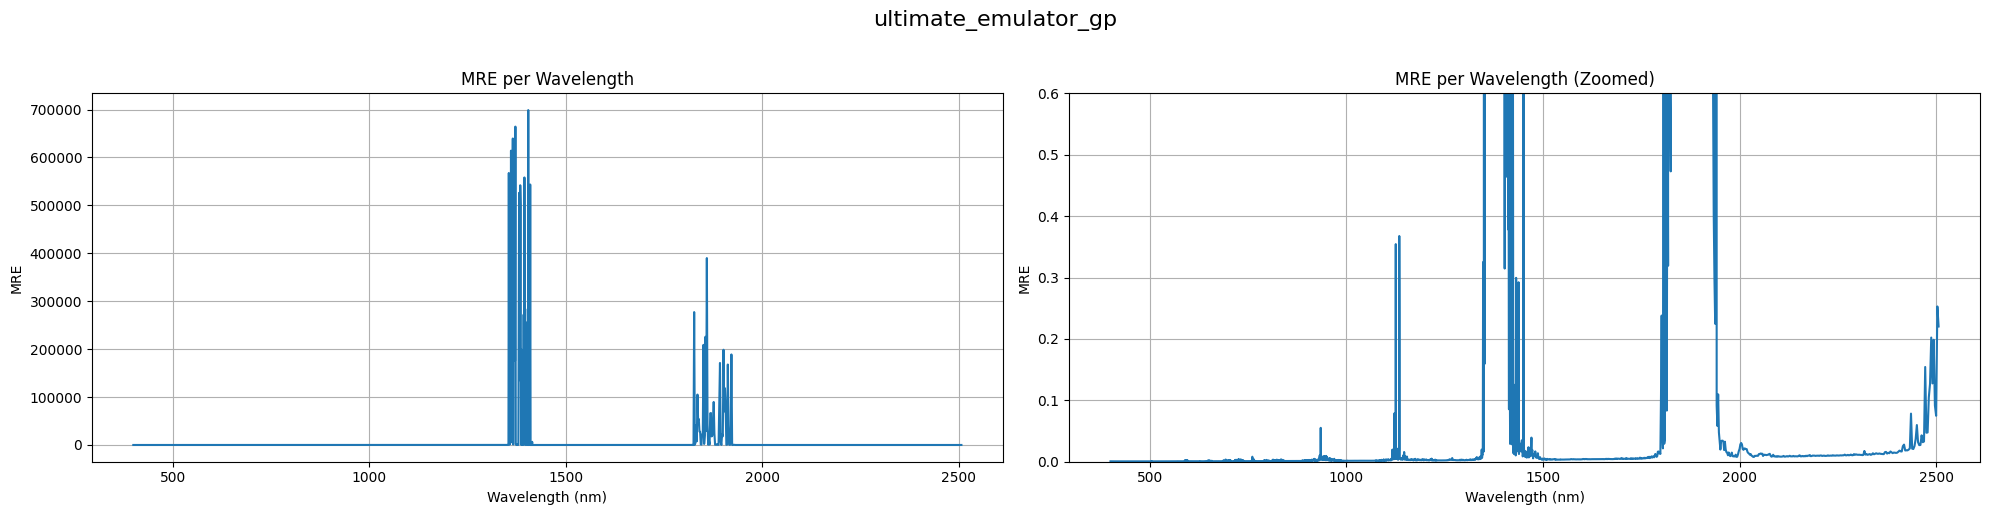

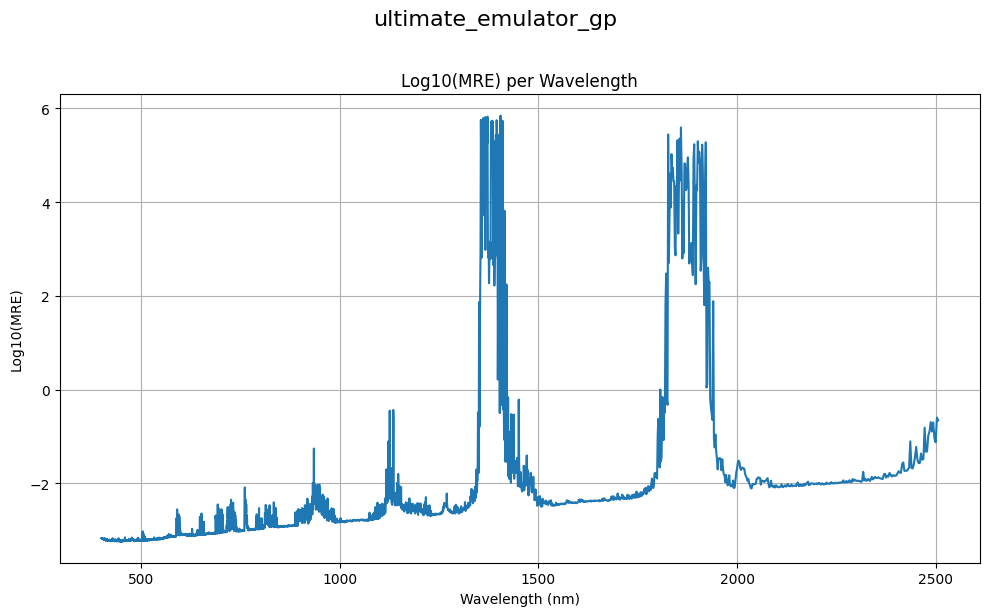

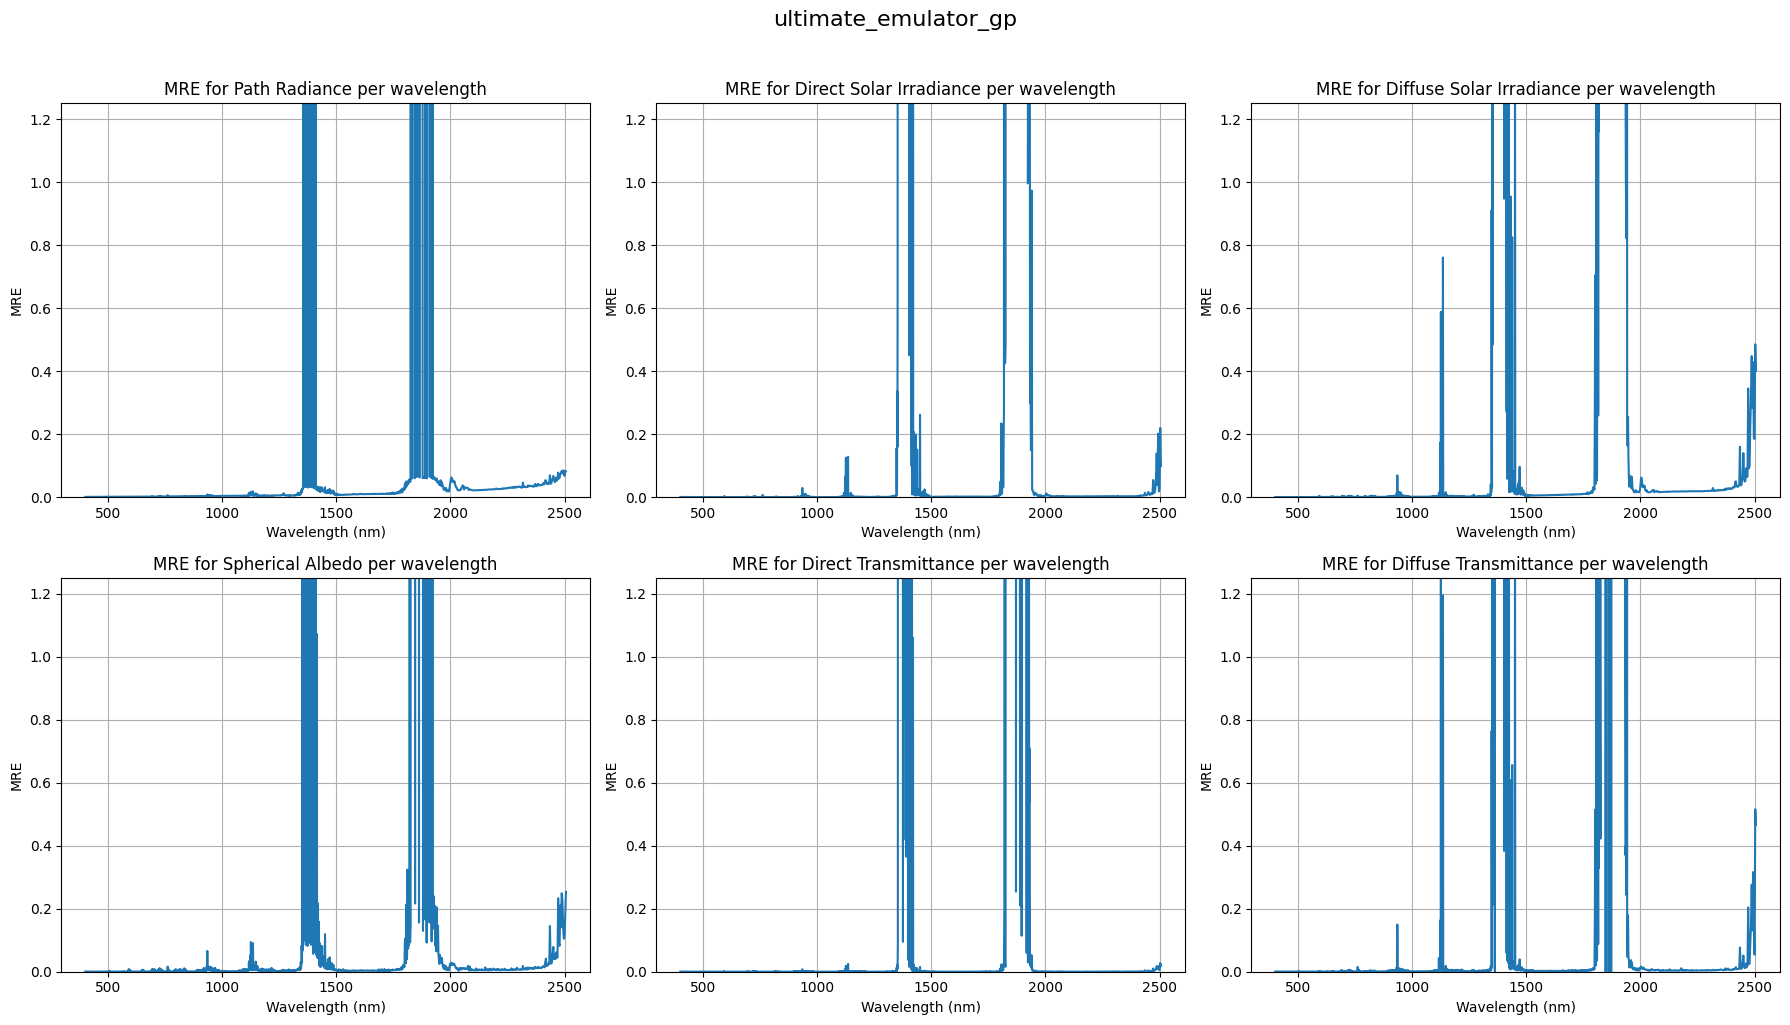

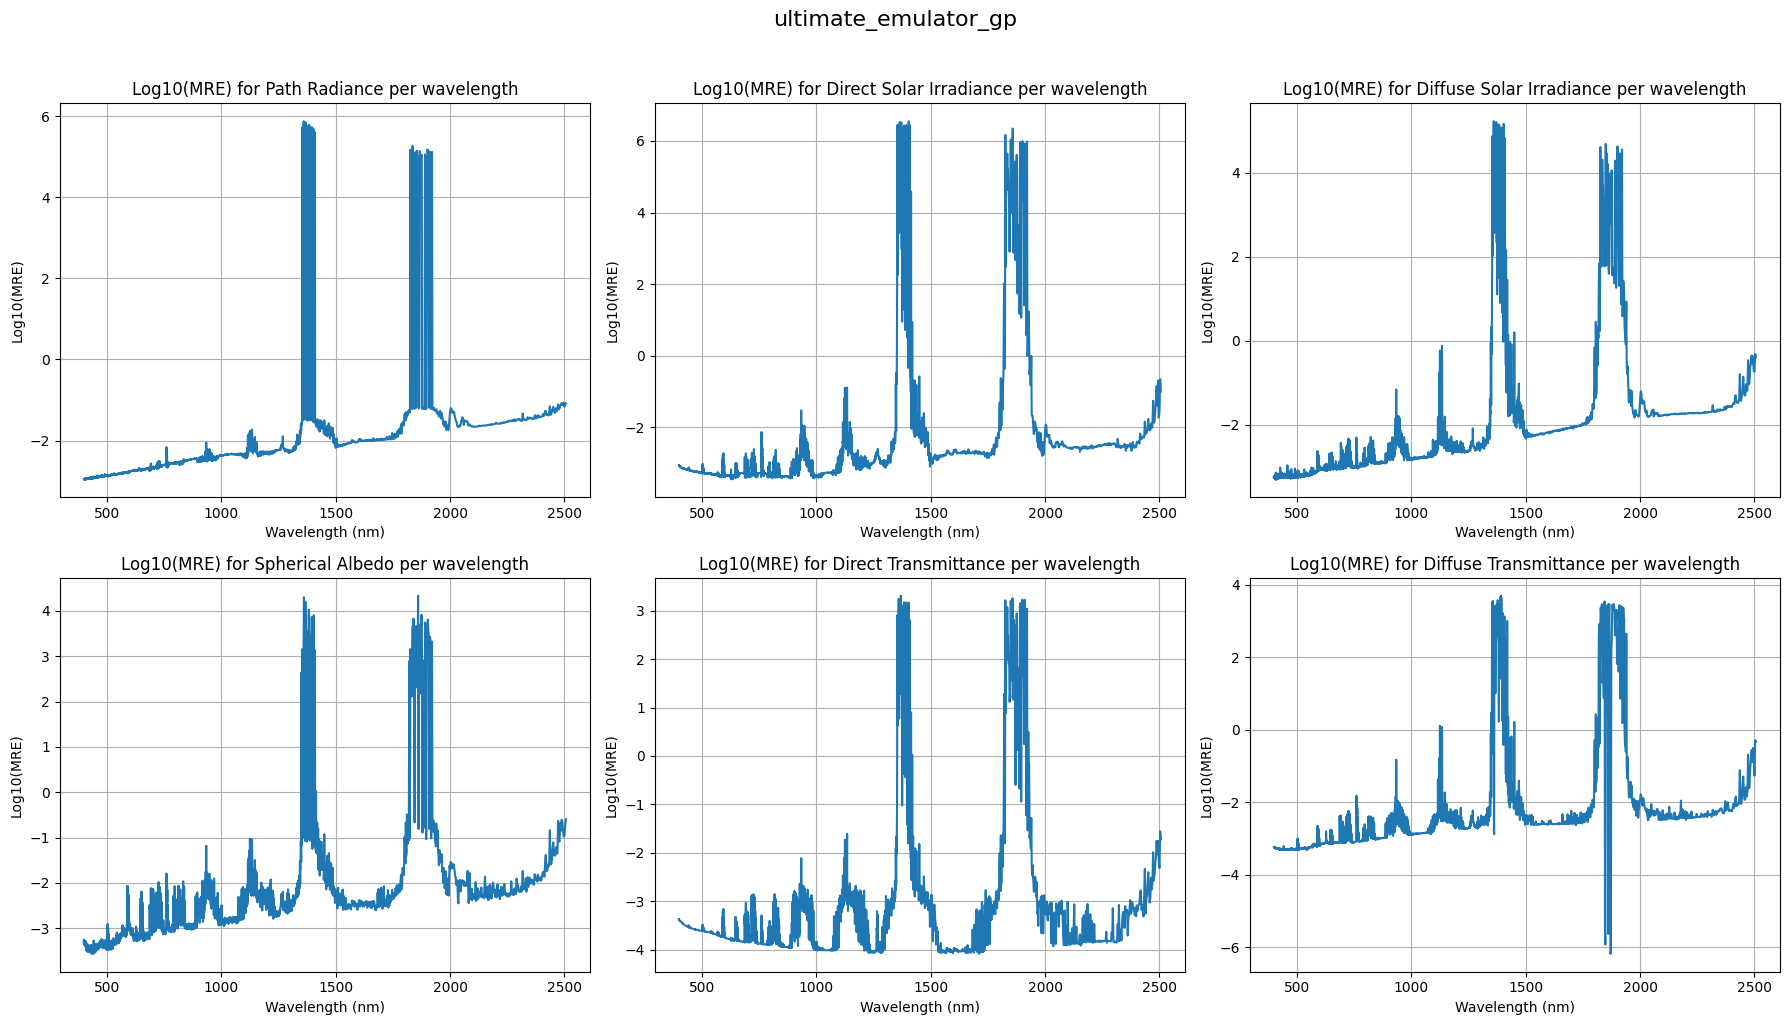

Testing MAE: 0.11642714252878586
Path Radiance MAE: 0.0315
Direct Solar Irradiance MAE: 0.4590
Diffuse Solar Irradiance MAE: 0.2076
Spherical Albedo MAE: 0.0001
Direct Transmittance MAE: 0.0002
Diffuse Transmittance MAE: 0.0002


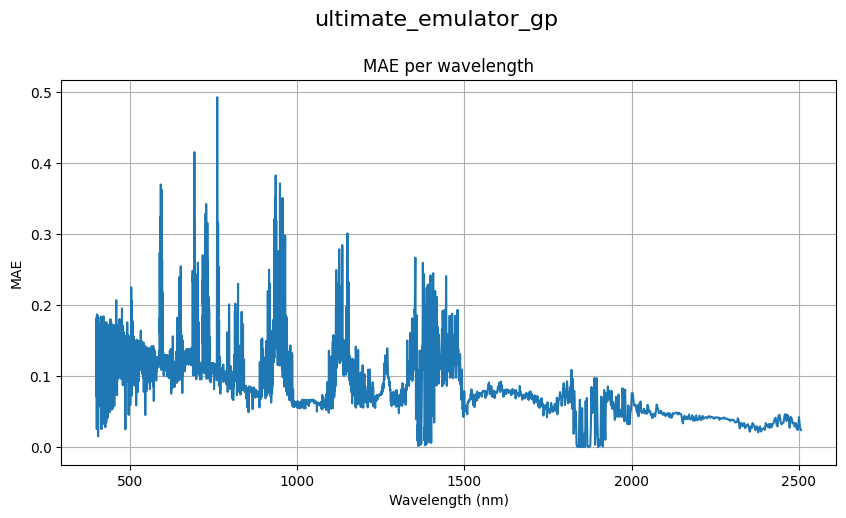

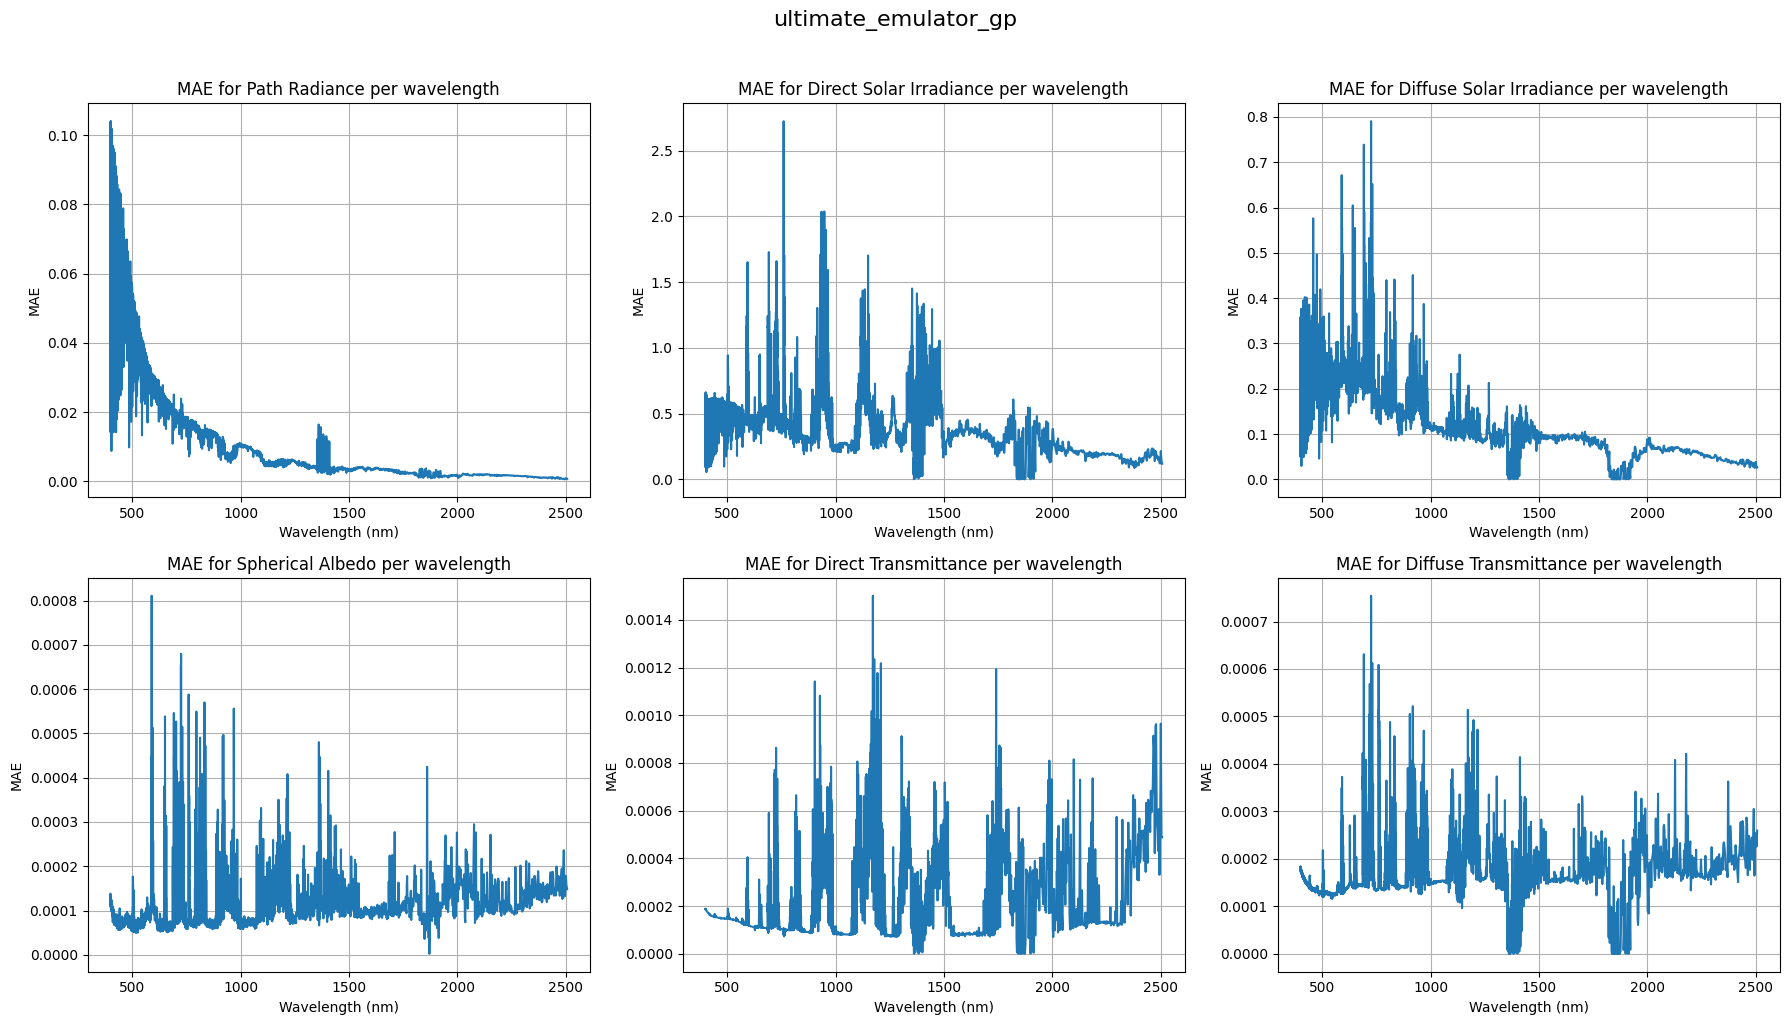

Global Coverage Probability (2σ): 95.57%
------------------------------
Path Radiance   Coverage: 94.38%
Direct Solar Irradiance Coverage: 94.45%
Diffuse Solar Irradiance Coverage: 94.60%
Spherical Albedo Coverage: 95.75%
Direct Transmittance Coverage: 97.80%
Diffuse Transmittance Coverage: 96.42%


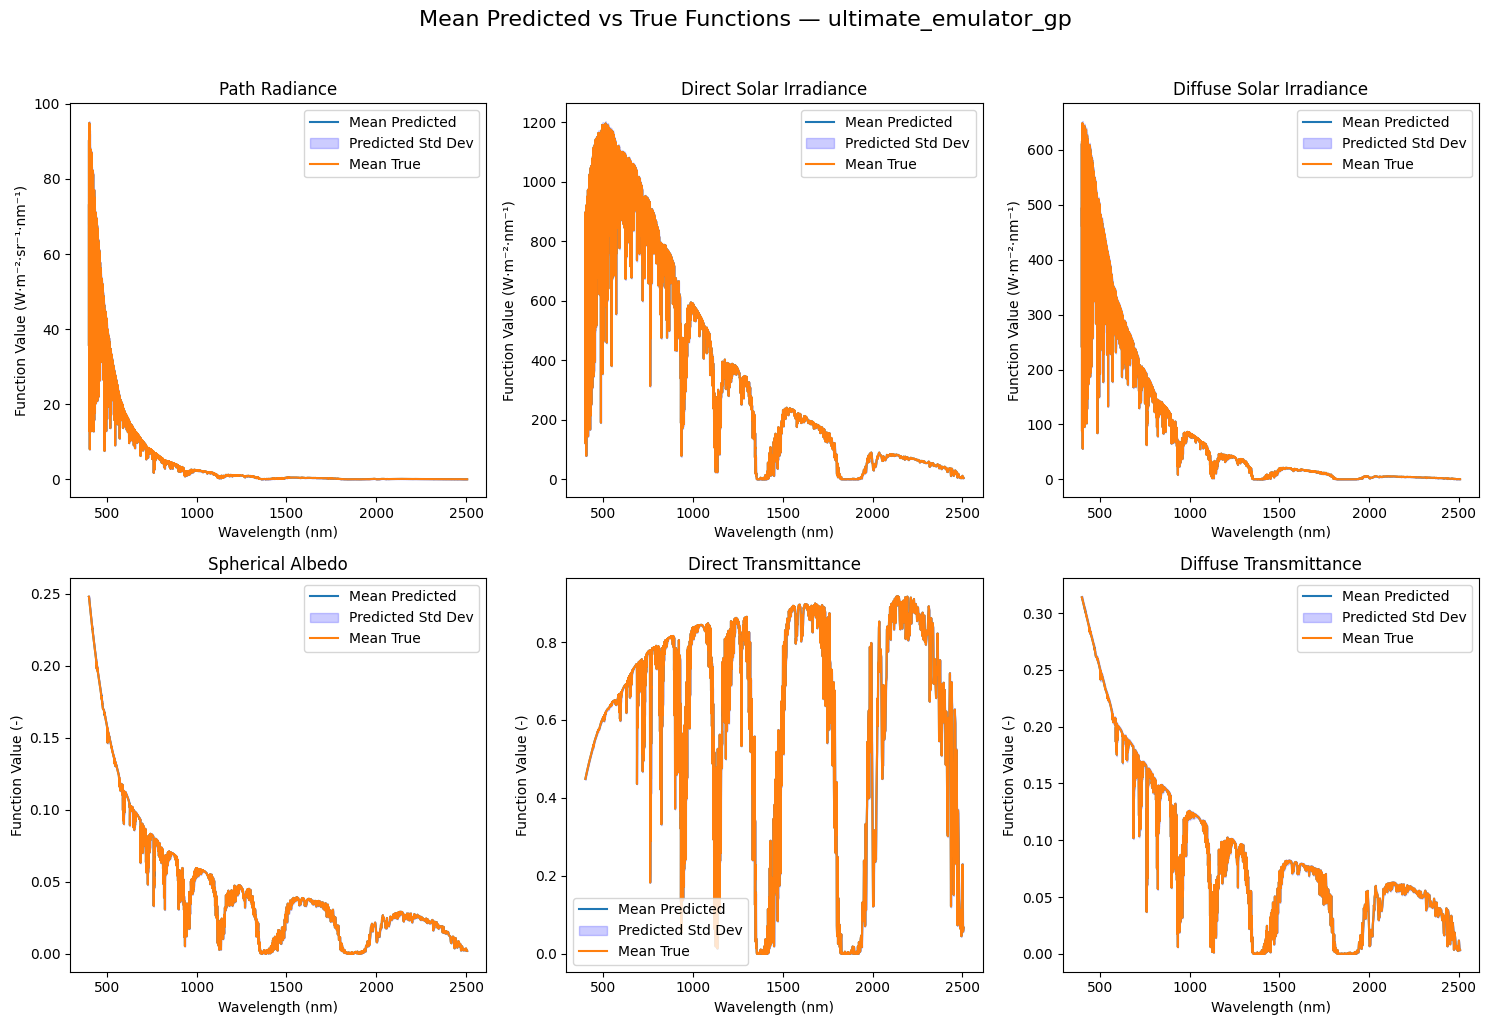

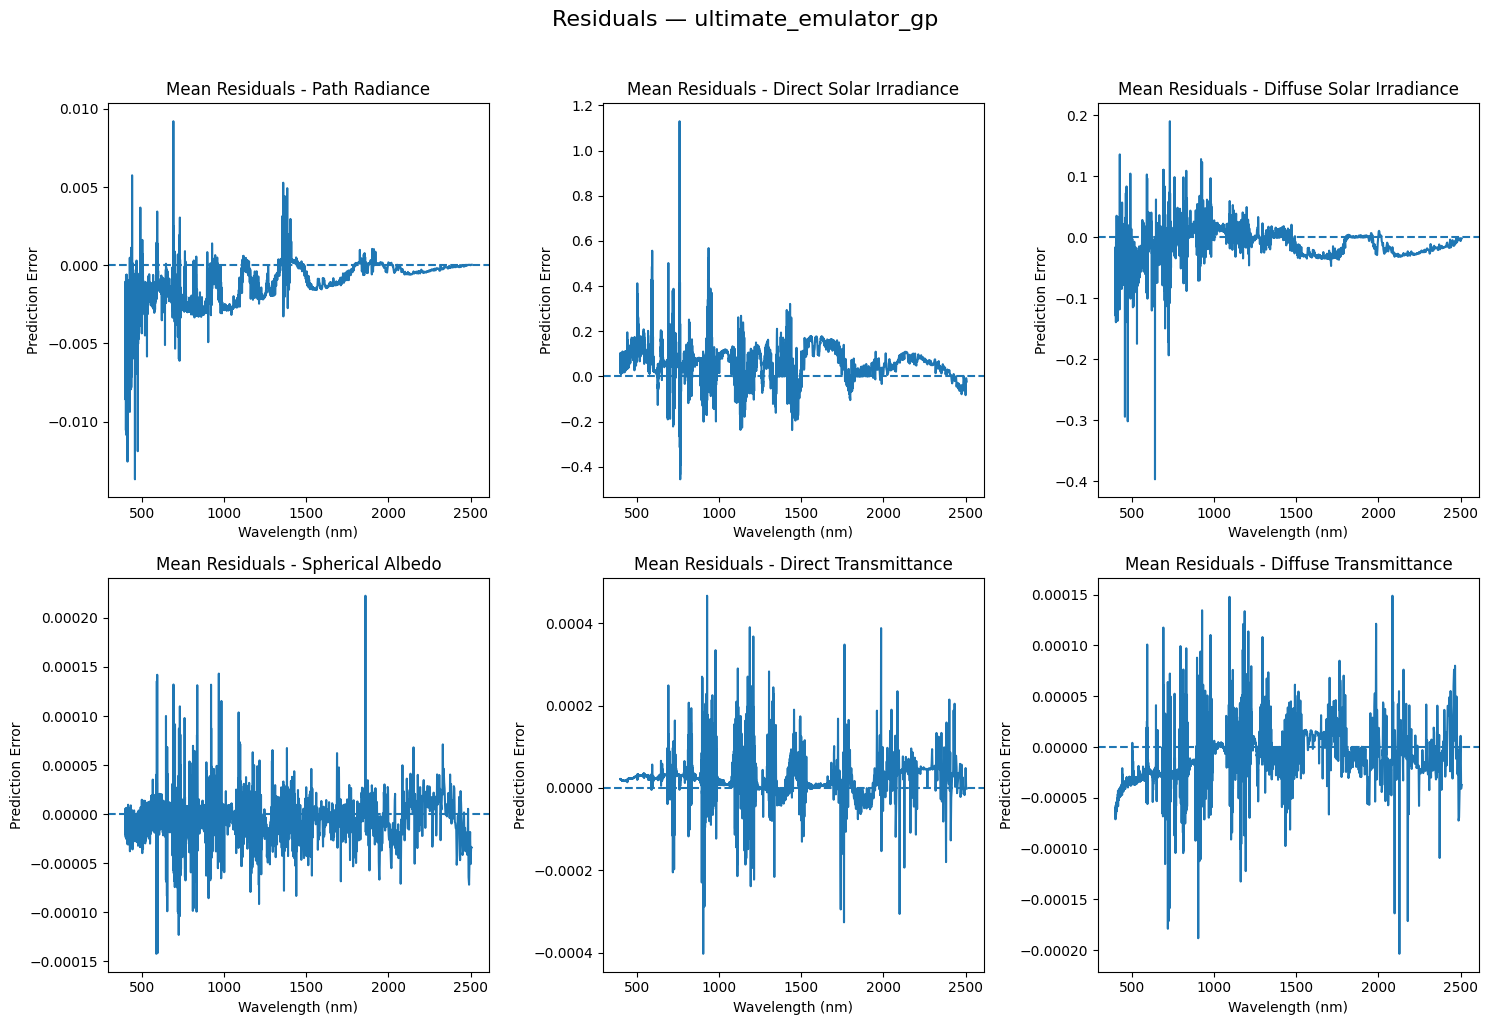

In [18]:
mre_val = utils.mre_score(Y_val, Y_val_pred_pc, wavelengths, axis=None)
mae_val = utils.mae_score(Y_val, Y_val_pred_pc, wavelengths, axis=None)
print(f"Ultimate Emulator Validation MRE: {mre_val}")
print(f"Ultimate Emulator Validation MAE: {mae_val}\n\n")

test_mre, test_mre_per_func = utils.show_test_results_mre(Y_test, Y_test_pred_pc, wavelengths, exp_id="ultimate_emulator_gp", save_path="gp_saves/testing_results/")
test_mae, test_mae_per_func = utils.show_test_results_mae(Y_test, Y_test_pred_pc, wavelengths, exp_id="ultimate_emulator_gp", save_path="gp_saves/testing_results/")

# --- coverage probability ---
global_cov, func_cov = utils.calculate_coverage(Y_test, Y_test_pred_pc, Y_test_std_pc)
print(f"Global Coverage Probability ({2}σ): {global_cov:.2f}%")
print("-" * 30)
for i, name in enumerate(globals.function_names_plots):
    print(f"{name:15} Coverage: {func_cov[i]:.2f}%")

utils.show_predicted_vs_true(Y_test, Y_test_pred_pc, Y_test_std_pc, wavelengths, exp_id="ultimate_emulator_gp", save_path="gp_saves/testing_results/")
utils.show_residuals(Y_test, Y_test_pred_pc, wavelengths, exp_id="ultimate_emulator_gp", save_path="gp_saves/testing_results/")